
# Financial News Sentiment + Price Momentum Project (Fixed Version)

这版 notebook 按**可重复运行**的顺序重构好了：

1. 读取并清洗新闻数据  
2. 聚合为 `stock-date` 日频新闻  
3. 下载价格并构造 `target / t1_ret / mom_5d / mom_10d / mom_20d / vol_5d / vol_20d / rsi_14 / volume_ratio`  
4. 用 FinBERT 提取 `pos / neg / neu`  
5. **显式生成 `final_df`**  
6. 跑分类比较、预测概率、回测与策略汇总

> 这版的关键修复点：不再依赖旧 kernel 里残留的 `final_df`，而是在 notebook 中现场构造它。


In [1]:

# 如第一次运行，可先安装依赖
# !pip install -q yfinance transformers torch scikit-learn matplotlib pandas numpy


In [2]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import torch
import torch.nn.functional as F

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', 120)

# ========= 配置区 =========
FILE_PATH = '/Users/lihuilin/Desktop/archive/analyst_ratings_processed.csv'  # 你的原路径
TEST_TICKERS = ['MRK', 'MS', 'MU', 'NVDA', 'QQQ', 'M', 'EBAY', 'NFLX', 'GILD', 'VZ']
USE_GPU_IF_AVAILABLE = True
FINBERT_BATCH_SIZE = 16
RANDOM_STATE = 42

from scipy.stats import spearmanr


In [3]:

# =========================
# 1) 读取并清洗新闻数据
# =========================
df = pd.read_csv(FILE_PATH)
print("raw columns:", df.columns.tolist())
print("raw shape:", df.shape)

news_df = df.copy()

if 'Unnamed: 0' in news_df.columns:
    news_df = news_df.drop(columns=['Unnamed: 0'])

news_df['date'] = pd.to_datetime(news_df['date'], errors='coerce', utc=True)
news_df = news_df.dropna(subset=['date', 'title', 'stock']).copy()
news_df['date'] = news_df['date'].dt.tz_localize(None).dt.normalize()
news_df['stock'] = news_df['stock'].astype(str).str.upper().str.strip()
news_df['title'] = news_df['title'].astype(str).str.strip()

news_df = news_df.drop_duplicates(subset=['title', 'stock', 'date']).copy()
news_df = news_df[news_df['stock'].isin(TEST_TICKERS)].copy()

print("cleaned news_df shape:", news_df.shape)
print("date range:", news_df['date'].min(), "->", news_df['date'].max())
print("tickers:", sorted(news_df['stock'].unique()))

# 聚合到 stock-date，同时保留当天新闻数
daily_news = (
    news_df.groupby(['stock', 'date'], as_index=False)
    .agg(
        title=('title', lambda s: ' '.join(s.astype(str))),
        news_count=('title', 'size')
    )
)

print("\ndaily_news shape:", daily_news.shape)
print(daily_news.head())


raw columns: ['Unnamed: 0', 'title', 'date', 'stock']
raw shape: (1400469, 4)
cleaned news_df shape: (30452, 3)
date range: 2009-06-16 00:00:00 -> 2020-06-11 00:00:00
tickers: ['EBAY', 'GILD', 'M', 'MRK', 'MS', 'MU', 'NFLX', 'NVDA', 'QQQ', 'VZ']

daily_news shape: (12459, 4)
  stock       date                                                                                                                    title  news_count
0  EBAY 2011-10-13  Not So Fast, Visa And Mastercard? Piper Jaffray Maintains Neutral Rating and $36 PT on eBay Benchmark Has Hold on eB...           5
1  EBAY 2011-10-14  Earnings Preview: eBay's EPS, Revenue Expected to Rise Six Reasons to Buy an iPhone 4S Right Now iPhone 4S Going for...           3
2  EBAY 2011-10-16                                                                         Earnings Expectations for the Week of October 17           1
3  EBAY 2011-10-17                                                                                         Jefferies

In [4]:

# =====================================
# 2) 下载价格并构造价格/标签特征
# =====================================
def compute_rsi(close: pd.Series, window: int = 14) -> pd.Series:
    delta = close.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(window).mean()
    avg_loss = loss.rolling(window).mean()
    rs = avg_gain / avg_loss.replace(0, np.nan)
    rsi = 100 - (100 / (1 + rs))
    return rsi

start_date = daily_news['date'].min() - pd.Timedelta(days=40)
end_date = daily_news['date'].max() + pd.Timedelta(days=10)

price_frames = []

for ticker in sorted(daily_news['stock'].unique()):
    print(f"downloading {ticker} ...")
    px = yf.download(
        ticker,
        start=start_date.strftime('%Y-%m-%d'),
        end=end_date.strftime('%Y-%m-%d'),
        progress=False,
        auto_adjust=False
    )

    if px.empty:
        print(f"  -> {ticker} empty, skipped")
        continue

    if isinstance(px.columns, pd.MultiIndex):
        px.columns = px.columns.get_level_values(0)

    px = px.reset_index()
    px.columns.name = None
    px['date'] = pd.to_datetime(px['Date']).dt.tz_localize(None).dt.normalize()
    px['stock'] = ticker

    rename_map = {
        'Open': 'open',
        'High': 'high',
        'Low': 'low',
        'Close': 'close_raw',
        'Adj Close': 'close',
        'Volume': 'volume'
    }
    px = px.rename(columns=rename_map)

    if 'close' not in px.columns and 'close_raw' in px.columns:
        px['close'] = px['close_raw']
    if 'close_raw' not in px.columns:
        px['close_raw'] = px['close']
    for col in ['open', 'high', 'low', 'volume']:
        if col not in px.columns:
            px[col] = np.nan

    px = px[['stock', 'date', 'open', 'high', 'low', 'close', 'close_raw', 'volume']].copy()
    px = px.sort_values(['stock', 'date']).reset_index(drop=True)

    # return / label
    px['ret_1d'] = px['close'].pct_change()
    px['next_close'] = px['close'].shift(-1)
    px['target'] = (px['next_close'] > px['close']).astype(float)
    px['t1_ret'] = px['next_close'] / px['close'] - 1

    # momentum
    px['mom_1d'] = px['ret_1d']
    px['mom_5d'] = px['close'] / px['close'].shift(5) - 1
    px['mom_10d'] = px['close'] / px['close'].shift(10) - 1
    px['mom_20d'] = px['close'] / px['close'].shift(20) - 1

    # volatility / volume
    px['vol_5d'] = px['ret_1d'].rolling(5).std()
    px['vol_20d'] = px['ret_1d'].rolling(20).std()
    px['volume_change'] = px['volume'].pct_change()
    px['volume_ratio'] = px['volume'] / px['volume'].rolling(20).mean()

    # intraday / gap
    px['range'] = (px['high'] - px['low']) / px['close'].replace(0, np.nan)
    px['prev_close'] = px['close'].shift(1)
    px['gap'] = px['open'] / px['prev_close'] - 1

    # RSI
    px['rsi_14'] = compute_rsi(px['close'], 14)

    price_frames.append(px)

price_df = pd.concat(price_frames, ignore_index=True)
price_df = price_df.sort_values(['stock', 'date']).reset_index(drop=True)

print("\nprice_df shape:", price_df.shape)
print(price_df.head())


downloading EBAY ...
downloading GILD ...
downloading M ...
downloading MRK ...
downloading MS ...
downloading MU ...
downloading NFLX ...
downloading NVDA ...
downloading QQQ ...
downloading VZ ...

price_df shape: (28000, 24)
  stock       date      open      high       low     close  close_raw    volume    ret_1d  next_close  target    t1_ret    mom_1d  mom_5d  mom_10d  mom_20d  vol_5d  vol_20d  volume_change  \
0  EBAY 2009-05-07  7.344276  7.398990  6.919192  6.249302   7.045455  47031494       NaN    6.488225     1.0  0.038232       NaN     NaN      NaN      NaN     NaN      NaN            NaN   
1  EBAY 2009-05-08  7.100168  7.398990  7.070707  6.488225   7.314815  41299870  0.038232    6.432226     0.0 -0.008631  0.038232     NaN      NaN      NaN     NaN      NaN      -0.121868   
2  EBAY 2009-05-11  7.175926  7.361111  7.100168  6.432226   7.251684  26638286 -0.008631    6.372495     0.0 -0.009286 -0.008631     NaN      NaN      NaN     NaN      NaN      -0.355003   
3  EBAY 

In [5]:

# =========================================
# 3) 把价格特征并回 daily_news，得到基础主表
# =========================================
price_feature_cols = [
    'stock', 'date', 'target', 't1_ret',
    'mom_1d', 'mom_5d', 'mom_10d', 'mom_20d',
    'vol_5d', 'vol_20d', 'volume_change', 'volume_ratio',
    'range', 'gap', 'rsi_14'
]

base_df = daily_news.merge(
    price_df[price_feature_cols].copy(),
    on=['stock', 'date'],
    how='left'
)

print("base_df shape:", base_df.shape)
print(base_df.head())
print("\nmissing rate:")
for c in ['target', 't1_ret', 'mom_1d', 'mom_5d', 'mom_10d', 'vol_5d', 'volume_change']:
    print(f"{c}: {base_df[c].isna().mean():.4f}")


base_df shape: (12459, 17)
  stock       date                                                                                                                    title  news_count  target    t1_ret    mom_1d    mom_5d  \
0  EBAY 2011-10-13  Not So Fast, Visa And Mastercard? Piper Jaffray Maintains Neutral Rating and $36 PT on eBay Benchmark Has Hold on eB...           5     1.0  0.029017 -0.000306  0.041348   
1  EBAY 2011-10-14  Earnings Preview: eBay's EPS, Revenue Expected to Rise Six Reasons to Buy an iPhone 4S Right Now iPhone 4S Going for...           3     0.0 -0.013951  0.029017  0.084325   
2  EBAY 2011-10-16                                                                         Earnings Expectations for the Week of October 17           1     NaN       NaN       NaN       NaN   
3  EBAY 2011-10-17                                                                                         Jefferies Reiterates Buy on eBay           1     1.0  0.019566 -0.013951  0.028483   
4  EBAY 

In [6]:

# =========================================
# 4) FinBERT 提取情感分数（batched）
# =========================================
device = 'cuda' if (USE_GPU_IF_AVAILABLE and torch.cuda.is_available()) else 'cpu'
print("device:", device)

tokenizer = AutoTokenizer.from_pretrained('ProsusAI/finbert')
model = AutoModelForSequenceClassification.from_pretrained('ProsusAI/finbert').to(device)
model.eval()

id2label = {int(k): v.lower() for k, v in model.config.id2label.items()}
print("FinBERT labels:", id2label)

def finbert_score_texts(texts, batch_size=16):
    outputs_all = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        encoded = tokenizer(
            batch,
            return_tensors='pt',
            padding=True,
            truncation=True,
            max_length=512
        )
        encoded = {k: v.to(device) for k, v in encoded.items()}

        with torch.no_grad():
            logits = model(**encoded).logits
            probs = F.softmax(logits, dim=-1).detach().cpu().numpy()

        outputs_all.append(probs)

    probs = np.vstack(outputs_all)

    # 按 label 名称稳健映射，而不是硬编码列顺序
    score_df = pd.DataFrame({
        'pos': probs[:, [k for k, v in id2label.items() if 'pos' in v][0]],
        'neg': probs[:, [k for k, v in id2label.items() if 'neg' in v][0]],
        'neu': probs[:, [k for k, v in id2label.items() if 'neu' in v][0]],
    })
    return score_df

sentiment_df = finbert_score_texts(base_df['title'].fillna('').astype(str).tolist(), batch_size=FINBERT_BATCH_SIZE)
print("sentiment_df shape:", sentiment_df.shape)
print(sentiment_df.head())


device: cpu


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


FinBERT labels: {0: 'positive', 1: 'negative', 2: 'neutral'}


sentiment_df shape: (12459, 3)
        pos       neg       neu
0  0.049313  0.768900  0.181786
1  0.805207  0.017252  0.177541
2  0.033712  0.258975  0.707312
3  0.057471  0.060699  0.881829
4  0.020641  0.580844  0.398515


In [8]:

# =========================================
# 5) 显式生成 final_df（关键修复）
# =========================================
final_df = pd.concat(
    [base_df.reset_index(drop=True), sentiment_df.reset_index(drop=True)],
    axis=1
)

# 统一字段类型
final_df['date'] = pd.to_datetime(final_df['date']).dt.tz_localize(None).dt.normalize()
final_df['stock'] = final_df['stock'].astype(str).str.upper().str.strip()

# 兼容旧代码
final_df['momentum'] = final_df['mom_5d']

# 新增更可解释的情绪特征
final_df['sent_net'] = final_df['pos'] - final_df['neg']
final_df['sent_abs'] = final_df['sent_net'].abs()

# 删除没有标签/没有核心特征的行
final_df = final_df.dropna(subset=['target', 'pos', 'neg', 'neu']).reset_index(drop=True)

required_cols = [
    'stock', 'date', 'title', 'news_count',
    'target', 't1_ret',
    'pos', 'neg', 'neu', 'sent_net',
    'mom_1d', 'mom_5d', 'mom_10d', 'vol_5d',
    'volume_change', 'range', 'gap'
]
missing_required = [c for c in required_cols if c not in final_df.columns]
assert not missing_required, f"final_df missing required columns: {missing_required}"

print("final_df columns =", final_df.columns.tolist())
print("final_df shape =", final_df.shape)
print(final_df[['stock', 'date', 'news_count', 'pos', 'neg', 'neu', 'sent_net', 'mom_1d', 'mom_5d', 'vol_5d', 'target']].head())


final_df columns = ['stock', 'date', 'title', 'news_count', 'target', 't1_ret', 'mom_1d', 'mom_5d', 'mom_10d', 'mom_20d', 'vol_5d', 'vol_20d', 'volume_change', 'volume_ratio', 'range', 'gap', 'rsi_14', 'pos', 'neg', 'neu', 'momentum', 'sent_net', 'sent_abs']
final_df shape = (11589, 23)
  stock       date  news_count       pos       neg       neu  sent_net    mom_1d    mom_5d    vol_5d  target
0  EBAY 2011-10-13           5  0.049313  0.768900  0.181786 -0.719587 -0.000306  0.041348  0.020228     1.0
1  EBAY 2011-10-14           3  0.805207  0.017252  0.177541  0.787955  0.029017  0.084325  0.018240     0.0
2  EBAY 2011-10-17           1  0.057471  0.060699  0.881829 -0.003228 -0.013951  0.028483  0.016932     1.0
3  EBAY 2011-10-18           2  0.020641  0.580844  0.398515 -0.560203  0.019566  0.031678  0.017479     0.0
4  EBAY 2011-10-19           7  0.233076  0.311505  0.455418 -0.078429 -0.020372  0.013129  0.021187     0.0


In [9]:

# =========================================
# 6) sentiment-only vs sentiment+mom_5d（保留原主线）
# =========================================
model_df = final_df[['date', 'target', 'pos', 'neg', 'neu', 'sent_net', 'news_count', 'mom_5d']].dropna().copy()
model_df['date'] = pd.to_datetime(model_df['date'])
model_df = model_df.sort_values('date').reset_index(drop=True)

split_idx = int(len(model_df) * 0.8)
train_df = model_df.iloc[:split_idx].copy()
test_df = model_df.iloc[split_idx:].copy()

X_train_sent = train_df[['pos', 'neg', 'neu', 'sent_net', 'news_count']]
X_test_sent = test_df[['pos', 'neg', 'neu', 'sent_net', 'news_count']]
X_train_mf = train_df[['pos', 'neg', 'neu', 'sent_net', 'news_count', 'mom_5d']]
X_test_mf = test_df[['pos', 'neg', 'neu', 'sent_net', 'news_count', 'mom_5d']]
y_train = train_df['target'].astype(int)
y_test = test_df['target'].astype(int)

lr_model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE))
])

lr_model.fit(X_train_sent, y_train)
proba_sent = lr_model.predict_proba(X_test_sent)[:, 1]
auc_sent = roc_auc_score(y_test, proba_sent)

lr_model.fit(X_train_mf, y_train)
proba_mf = lr_model.predict_proba(X_test_mf)[:, 1]
auc_mf = roc_auc_score(y_test, proba_mf)

print("sentiment only AUC     =", round(auc_sent, 4))
print("sentiment + mom_5d AUC =", round(auc_mf, 4))
print("AUC gain               =", round(auc_mf - auc_sent, 4))


sentiment only AUC     = 0.5097
sentiment + mom_5d AUC = 0.5214
AUC gain               = 0.0117


In [10]:

# =========================================
# 7) Logistic Regression: 三组特征比较
# =========================================
cmp_cols = [
    'date', 'target',
    'pos', 'neg', 'neu', 'sent_net', 'news_count',
    'mom_1d', 'mom_5d', 'mom_10d', 'vol_5d',
    'volume_change', 'range', 'gap'
]
cmp_df = final_df[cmp_cols].dropna().copy()
cmp_df['date'] = pd.to_datetime(cmp_df['date'])
cmp_df = cmp_df.sort_values('date').reset_index(drop=True)

split_idx = int(len(cmp_df) * 0.8)
train_df = cmp_df.iloc[:split_idx].copy()
test_df = cmp_df.iloc[split_idx:].copy()

y_train = train_df['target'].astype(int)
y_test = test_df['target'].astype(int)

feature_sets = {
    'sentiment_only': ['pos', 'neg', 'neu', 'sent_net', 'news_count'],
    'price_only': ['mom_1d', 'mom_5d', 'mom_10d', 'vol_5d', 'volume_change', 'range', 'gap'],
    'sentiment_price': ['pos', 'neg', 'neu', 'sent_net', 'news_count', 'mom_1d', 'mom_5d', 'mom_10d', 'vol_5d', 'volume_change', 'range', 'gap']
}

lr_model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE))
])

results = []
for name, cols in feature_sets.items():
    lr_model.fit(train_df[cols], y_train)
    proba = lr_model.predict_proba(test_df[cols])[:, 1]
    pred = (proba >= 0.5).astype(int)
    results.append({
        'feature_set': name,
        'n_features': len(cols),
        'auc': roc_auc_score(y_test, proba),
        'accuracy': accuracy_score(y_test, pred),
        'f1': f1_score(y_test, pred)
    })

results_df = pd.DataFrame(results).sort_values('auc', ascending=False).reset_index(drop=True)
print(results_df.round(4))


       feature_set  n_features     auc  accuracy      f1
0   sentiment_only           5  0.5097    0.5246  0.5931
1       price_only           7  0.5073    0.4983  0.5066
2  sentiment_price          12  0.5033    0.4974  0.5437


In [11]:

# =========================================
# 8) 三模型 x 三组特征比较
# =========================================
compare_cols = [
    'date', 'target',
    'pos', 'neg', 'neu', 'sent_net', 'news_count',
    'mom_1d', 'mom_5d', 'mom_10d', 'vol_5d',
    'volume_change', 'range', 'gap'
]
compare_df = final_df[compare_cols].dropna().copy()
compare_df['date'] = pd.to_datetime(compare_df['date'])
compare_df = compare_df.sort_values('date').reset_index(drop=True)

split_idx = int(len(compare_df) * 0.8)
train_df = compare_df.iloc[:split_idx].copy()
test_df = compare_df.iloc[split_idx:].copy()

y_train = train_df['target'].astype(int)
y_test = test_df['target'].astype(int)

feature_sets = {
    'sentiment_only': ['pos', 'neg', 'neu', 'sent_net', 'news_count'],
    'price_only': ['mom_1d', 'mom_5d', 'mom_10d', 'vol_5d', 'volume_change', 'range', 'gap'],
    'sentiment_price': ['pos', 'neg', 'neu', 'sent_net', 'news_count', 'mom_1d', 'mom_5d', 'mom_10d', 'vol_5d', 'volume_change', 'range', 'gap']
}

models = {
    'LogReg': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE))
    ]),
    'RandomForest': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('clf', RandomForestClassifier(
            n_estimators=300,
            max_depth=6,
            min_samples_leaf=20,
            class_weight='balanced_subsample',
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),
    'GradientBoosting': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('clf', GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=2,
            subsample=0.8,
            random_state=RANDOM_STATE
        ))
    ])
}

results = []
for feat_name, cols in feature_sets.items():
    for model_name, model in models.items():
        model.fit(train_df[cols], y_train)
        proba = model.predict_proba(test_df[cols])[:, 1]
        pred = (proba >= 0.5).astype(int)
        results.append({
            'feature_set': feat_name,
            'model': model_name,
            'n_features': len(cols),
            'auc': roc_auc_score(y_test, proba),
            'accuracy': accuracy_score(y_test, pred),
            'f1': f1_score(y_test, pred)
        })

results_df_models = pd.DataFrame(results).sort_values(['auc', 'f1'], ascending=False).reset_index(drop=True)
print(results_df_models.round(4))
best_row = results_df_models.iloc[0].to_dict()
print("\nBest config:", best_row)


       feature_set             model  n_features     auc  accuracy      f1
0  sentiment_price  GradientBoosting          12  0.5135    0.5242  0.6346
1       price_only      RandomForest           7  0.5128    0.5104  0.5316
2  sentiment_price      RandomForest          12  0.5128    0.5138  0.5472
3   sentiment_only            LogReg           5  0.5097    0.5246  0.5931
4   sentiment_only  GradientBoosting           5  0.5086    0.5276  0.6532
5       price_only  GradientBoosting           7  0.5086    0.5224  0.6228
6       price_only            LogReg           7  0.5073    0.4983  0.5066
7  sentiment_price            LogReg          12  0.5033    0.4974  0.5437
8   sentiment_only      RandomForest           5  0.5025    0.5104  0.5792

Best config: {'feature_set': 'sentiment_price', 'model': 'GradientBoosting', 'n_features': 12, 'auc': 0.5135224725015063, 'accuracy': 0.5241587575496117, 'f1': 0.6346472341835044}


In [12]:

# =========================================
# 9) 训练最佳模型并生成测试集信号
# =========================================
signal_cols = [
    'stock', 'date', 'target', 't1_ret',
    'pos', 'neg', 'neu', 'sent_net', 'news_count',
    'mom_1d', 'mom_5d', 'mom_10d', 'vol_5d',
    'volume_change', 'range', 'gap'
]
signal_df = final_df[signal_cols].dropna().copy()
signal_df['date'] = pd.to_datetime(signal_df['date'])
signal_df = signal_df.sort_values('date').reset_index(drop=True)

split_idx = int(len(signal_df) * 0.8)
train_df = signal_df.iloc[:split_idx].copy()
test_df = signal_df.iloc[split_idx:].copy()

feature_map = {
    'sentiment_only': ['pos', 'neg', 'neu', 'sent_net', 'news_count'],
    'price_only': ['mom_1d', 'mom_5d', 'mom_10d', 'vol_5d', 'volume_change', 'range', 'gap'],
    'sentiment_price': ['pos', 'neg', 'neu', 'sent_net', 'news_count', 'mom_1d', 'mom_5d', 'mom_10d', 'vol_5d', 'volume_change', 'range', 'gap']
}
best_features = feature_map[best_row['feature_set']]

if best_row['model'] == 'LogReg':
    best_model = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE))
    ])
elif best_row['model'] == 'RandomForest':
    best_model = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('clf', RandomForestClassifier(
            n_estimators=300,
            max_depth=6,
            min_samples_leaf=20,
            class_weight='balanced_subsample',
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])
else:
    best_model = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('clf', GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=2,
            subsample=0.8,
            random_state=RANDOM_STATE
        ))
    ])

X_train = train_df[best_features]
y_train = train_df['target'].astype(int)
X_test = test_df[best_features]

best_model.fit(X_train, y_train)

test_df = test_df.copy()
test_df['pred_proba'] = best_model.predict_proba(X_test)[:, 1]
test_df['pred_label'] = (test_df['pred_proba'] >= 0.5).astype(int)
test_df['long_signal'] = (test_df['pred_proba'] >= 0.55).astype(int)

print("best model =", best_row['model'])
print("best feature set =", best_row['feature_set'])
print("test_df shape:", test_df.shape)
print(test_df[['stock', 'date', 'target', 'pred_proba', 'pred_label', 'long_signal', 't1_ret']].head(10))


best model = GradientBoosting
best feature set = sentiment_price
test_df shape: (2318, 19)
     stock       date  target  pred_proba  pred_label  long_signal    t1_ret
9271  EBAY 2018-11-23     1.0    0.505885           1            0  0.012658
9272    VZ 2018-11-23     1.0    0.405611           0            0  0.009038
9273     M 2018-11-26     1.0    0.559379           1            1  0.040848
9274   QQQ 2018-11-26     1.0    0.568138           1            1  0.003376
9275   MRK 2018-11-26     1.0    0.538748           1            0  0.011930
9276  NVDA 2018-11-26     1.0    0.477345           0            0  0.004443
9277     M 2018-11-27     1.0    0.550801           1            1  0.015639
9278  NFLX 2018-11-27     1.0    0.541925           1            0  0.060083
9279  EBAY 2018-11-27     1.0    0.538364           1            0  0.035491
9280   MRK 2018-11-27     1.0    0.505290           1            0  0.011658


In [13]:

# =========================================
# 10) 排序能力：Rank IC + Long-Short
# =========================================
rank_df = test_df[['date', 'stock', 'pred_proba', 't1_ret']].dropna().copy()

daily_rank_ic = (
    rank_df.groupby('date')
    .apply(lambda x: spearmanr(x['pred_proba'], x['t1_ret'])[0] if x['stock'].nunique() >= 3 else np.nan)
    .dropna()
)

rank_ic_mean = daily_rank_ic.mean()
rank_ic_std = daily_rank_ic.std()
rank_ic_ir = rank_ic_mean / rank_ic_std if rank_ic_std not in [0, np.nan] else np.nan

rank_df['n_daily'] = rank_df.groupby('date')['stock'].transform('count')
rank_df['rank_desc'] = rank_df.groupby('date')['pred_proba'].rank(method='first', ascending=False)
rank_df['top_k'] = np.ceil(rank_df['n_daily'] * 0.2).astype(int).clip(lower=1)

top_leg = rank_df[rank_df['rank_desc'] <= rank_df['top_k']].groupby('date')['t1_ret'].mean()
bottom_leg = rank_df[rank_df['rank_desc'] > (rank_df['n_daily'] - rank_df['top_k'])].groupby('date')['t1_ret'].mean()
long_short = (top_leg - bottom_leg).dropna()

print("Mean Rank IC =", round(rank_ic_mean, 4))
print("Rank IC IR   =", round(rank_ic_ir, 4))
print("Long-short mean daily return =", round(long_short.mean(), 6))
print("Long-short annualized (simple) =", round(long_short.mean() * 252, 4))


Mean Rank IC = 0.0546
Rank IC IR   = 0.1155
Long-short mean daily return = 0.003821
Long-short annualized (simple) = 0.963


In [14]:

# =========================================
# 11A) 回测指标函数
# =========================================
def max_drawdown(nav_series):
    running_max = nav_series.cummax()
    drawdown = nav_series / running_max - 1
    return drawdown.min()

def annualized_return(nav_series, periods_per_year=252):
    n = len(nav_series)
    if n == 0:
        return np.nan
    return nav_series.iloc[-1] ** (periods_per_year / n) - 1

def annualized_vol(ret_series, periods_per_year=252):
    return ret_series.std() * np.sqrt(periods_per_year)

def sharpe_ratio(ret_series, periods_per_year=252):
    vol = annualized_vol(ret_series, periods_per_year)
    if vol == 0 or np.isnan(vol):
        return np.nan
    return ret_series.mean() / ret_series.std() * np.sqrt(periods_per_year)


In [15]:

# =========================================
# 11) 含交易成本的回测工具
# =========================================
COST_BPS = 10
COST_RATE = COST_BPS / 10000

def summarize_nav(ret_series):
    nav = (1 + ret_series).cumprod()
    win = (ret_series > 0).mean()
    ann_ret = annualized_return(nav)
    ann_vol = annualized_vol(ret_series)
    sr = sharpe_ratio(ret_series)
    mdd = max_drawdown(nav)
    return nav, win, ann_ret, ann_vol, sr, mdd

def backtest_threshold(df, threshold=0.55, cost_rate=COST_RATE):
    rows = []
    prev_hold = set()

    for dt, g in df.groupby('date'):
        g = g.sort_values('pred_proba', ascending=False).copy()
        pick = g[g['pred_proba'] >= threshold].copy()
        hold = set(pick['stock'])

        gross_ret = pick['t1_ret'].mean() if len(pick) > 0 else 0.0
        baseline_ret = g['t1_ret'].mean()

        if len(prev_hold) == 0:
            turnover = 1.0 if len(hold) > 0 else 0.0
        else:
            union = len(prev_hold | hold)
            turnover = 0.0 if union == 0 else 1 - len(prev_hold & hold) / union

        net_ret = gross_ret - turnover * cost_rate
        rows.append([dt, gross_ret, net_ret, baseline_ret, len(hold), turnover])
        prev_hold = hold

    out = pd.DataFrame(rows, columns=['date', 'gross_ret', 'net_ret', 'baseline_ret', 'n_hold', 'turnover']).sort_values('date')
    return out

def backtest_topk(df, k=1, cost_rate=COST_RATE):
    rows = []
    prev_hold = set()

    for dt, g in df.groupby('date'):
        g = g.sort_values('pred_proba', ascending=False).copy()
        k_use = min(k, len(g))
        pick = g.head(k_use).copy()
        hold = set(pick['stock'])

        gross_ret = pick['t1_ret'].mean()
        baseline_ret = g['t1_ret'].mean()

        if len(prev_hold) == 0:
            turnover = 1.0 if len(hold) > 0 else 0.0
        else:
            union = len(prev_hold | hold)
            turnover = 0.0 if union == 0 else 1 - len(prev_hold & hold) / union

        net_ret = gross_ret - turnover * cost_rate
        rows.append([dt, gross_ret, net_ret, baseline_ret, k_use, turnover])
        prev_hold = hold

    out = pd.DataFrame(rows, columns=['date', 'gross_ret', 'net_ret', 'baseline_ret', 'n_hold', 'turnover']).sort_values('date')
    return out

def backtest_topq(df, q=0.2, cost_rate=COST_RATE):
    rows = []
    prev_hold = set()

    for dt, g in df.groupby('date'):
        g = g.sort_values('pred_proba', ascending=False).copy()
        k = max(1, int(np.ceil(len(g) * q)))
        pick = g.head(k).copy()
        hold = set(pick['stock'])

        gross_ret = pick['t1_ret'].mean()
        baseline_ret = g['t1_ret'].mean()

        if len(prev_hold) == 0:
            turnover = 1.0 if len(hold) > 0 else 0.0
        else:
            union = len(prev_hold | hold)
            turnover = 0.0 if union == 0 else 1 - len(prev_hold & hold) / union

        net_ret = gross_ret - turnover * cost_rate
        rows.append([dt, gross_ret, net_ret, baseline_ret, k, turnover])
        prev_hold = hold

    out = pd.DataFrame(rows, columns=['date', 'gross_ret', 'net_ret', 'baseline_ret', 'n_hold', 'turnover']).sort_values('date')
    return out


In [16]:

# =========================================
# 12) 跑回测：Threshold / Top-1 / Top-3 / Top-5 / Top-20%
# =========================================
bt_df = test_df.dropna(subset=['t1_ret']).copy()

bt_threshold = backtest_threshold(bt_df, threshold=0.55)
bt_top1 = backtest_topk(bt_df, k=1)
bt_top3 = backtest_topk(bt_df, k=3)
bt_top5 = backtest_topk(bt_df, k=5)
bt_top20 = backtest_topq(bt_df, q=0.2)

for name, bt in [('Threshold(0.55)', bt_threshold), ('Top-1', bt_top1), ('Top-3', bt_top3), ('Top-5', bt_top5), ('Top-20%', bt_top20)]:
    nav, win, ann_ret, ann_vol, sr, mdd = summarize_nav(bt['net_ret'])
    print(name, 'final_nav=', round(nav.iloc[-1], 4), 'win=', round(win, 4), 'ann_ret=', round(ann_ret, 4), 'sharpe=', round(sr, 4), 'mdd=', round(mdd, 4))


Threshold(0.55) final_nav= 1.142 win= 0.3239 ann_ret= 0.0899 sharpe= 0.417 mdd= -0.3902
Top-1 final_nav= 2.254 win= 0.563 ann_ret= 0.693 sharpe= 1.2187 mdd= -0.3991
Top-3 final_nav= 1.251 win= 0.5193 ann_ret= 0.1561 sharpe= 0.5728 mdd= -0.3673
Top-5 final_nav= 1.2978 win= 0.545 ann_ret= 0.184 sharpe= 0.6569 mdd= -0.3233
Top-20% final_nav= 1.9958 win= 0.545 ann_ret= 0.5646 sharpe= 1.2038 mdd= -0.3123


In [17]:

# =========================================
# 13) 生成汇总表
# =========================================
summary_rows = []

for name, bt in [
    ('Threshold(0.55)', bt_threshold),
    ('Top-1', bt_top1),
    ('Top-3', bt_top3),
    ('Top-5', bt_top5),
    ('Top-20%', bt_top20),
]:
    nav, win, ann_ret, ann_vol, sr, mdd = summarize_nav(bt['net_ret'])
    base_nav = (1 + bt['baseline_ret']).cumprod()
    summary_rows.append({
        'strategy': name,
        'final_nav_net': nav.iloc[-1],
        'win_rate': win,
        'ann_return_net': ann_ret,
        'ann_vol_net': ann_vol,
        'sharpe_net': sr,
        'max_drawdown_net': mdd,
        'avg_turnover': bt['turnover'].mean(),
        'baseline_final_nav': base_nav.iloc[-1]
    })

summary_df = pd.DataFrame(summary_rows).sort_values('final_nav_net', ascending=False).reset_index(drop=True)
print(summary_df.round(4))


          strategy  final_nav_net  win_rate  ann_return_net  ann_vol_net  sharpe_net  max_drawdown_net  avg_turnover  baseline_final_nav
0            Top-1         2.2540    0.5630          0.6930       0.5619      1.2187           -0.3991        0.8458              1.3374
1          Top-20%         1.9958    0.5450          0.5646       0.4608      1.2038           -0.3123        0.8252              1.3374
2            Top-5         1.2978    0.5450          0.1840       0.3538      0.6569           -0.3233        0.6038              1.3374
3            Top-3         1.2510    0.5193          0.1561       0.3866      0.5728           -0.3673        0.7239              1.3374
4  Threshold(0.55)         1.1420    0.3239          0.0899       0.4227      0.4170           -0.3902        0.7131              1.3374


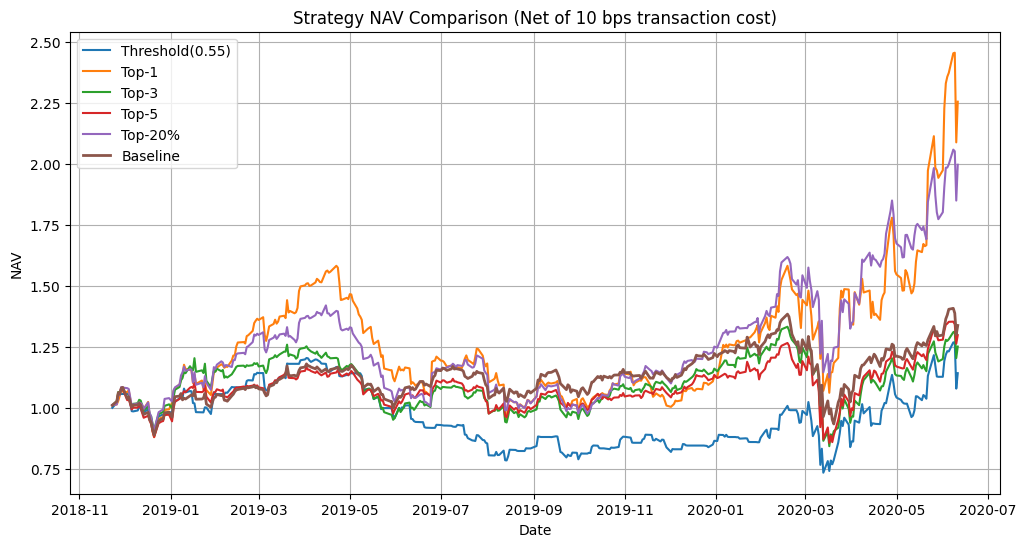

In [18]:

# =========================================
# 14) 画净值图（净收益，含10bps成本）
# =========================================
plot_map = {
    'Threshold(0.55)': bt_threshold,
    'Top-1': bt_top1,
    'Top-3': bt_top3,
    'Top-5': bt_top5,
    'Top-20%': bt_top20
}

plt.figure(figsize=(12, 6))
for name, bt in plot_map.items():
    nav = (1 + bt['net_ret']).cumprod()
    plt.plot(bt['date'], nav, label=name)

baseline_nav = (1 + bt_top1['baseline_ret']).cumprod()
plt.plot(bt_top1['date'], baseline_nav, label='Baseline', linewidth=2)

plt.title('Strategy NAV Comparison (Net of 10 bps transaction cost)')
plt.xlabel('Date')
plt.ylabel('NAV')
plt.legend()
plt.grid(True)
plt.show()


          strategy  final_nav  win_rate  ann_return  ann_vol  sharpe  max_drawdown
0            Top-1     2.2540    0.5630      0.6930   0.5619  1.2187       -0.3991
1          Top-20%     1.9958    0.5450      0.5646   0.4608  1.2038       -0.3123
2         Baseline     1.3374    0.5476      0.2072   0.3304  0.7365       -0.3250
3            Top-5     1.2978    0.5450      0.1840   0.3538  0.6569       -0.3233
4            Top-3     1.2510    0.5193      0.1561   0.3866  0.5728       -0.3673
5  Threshold(0.55)     1.1420    0.3239      0.0899   0.4227  0.4170       -0.3902


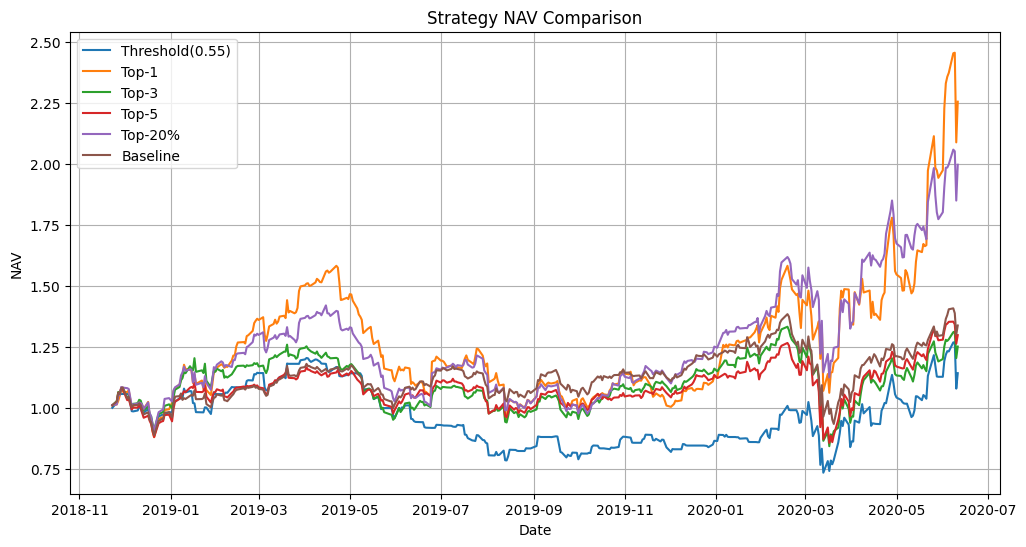

In [23]:
# =========================================
# 14) 策略汇总（适配你当前 bt_* 的列名）
# =========================================
def max_drawdown(nav_series):
    nav_series = pd.Series(nav_series).dropna()
    if len(nav_series) == 0:
        return np.nan
    running_max = nav_series.cummax()
    drawdown = nav_series / running_max - 1
    return drawdown.min()

def annualized_return(nav_series, periods_per_year=252):
    nav_series = pd.Series(nav_series).dropna()
    n = len(nav_series)
    if n == 0:
        return np.nan
    return nav_series.iloc[-1] ** (periods_per_year / n) - 1

def annualized_vol(ret_series, periods_per_year=252):
    ret_series = pd.Series(ret_series).dropna()
    if len(ret_series) == 0:
        return np.nan
    return ret_series.std() * np.sqrt(periods_per_year)

def sharpe_ratio(ret_series, periods_per_year=252):
    ret_series = pd.Series(ret_series).dropna()
    if len(ret_series) == 0 or ret_series.std() == 0:
        return np.nan
    return ret_series.mean() / ret_series.std() * np.sqrt(periods_per_year)

def add_nav_columns(bt_df):
    out = bt_df.sort_values('date').copy()
    out['nav'] = (1 + out['net_ret'].fillna(0)).cumprod()
    out['baseline_nav'] = (1 + out['baseline_ret'].fillna(0)).cumprod()
    return out

# 先给每个回测结果补上 nav
bt_threshold = add_nav_columns(bt_threshold)
bt_top1 = add_nav_columns(bt_top1)
bt_top3 = add_nav_columns(bt_top3)
bt_top5 = add_nav_columns(bt_top5)
bt_top20 = add_nav_columns(bt_top20)

summary_rows = [
    {
        'strategy': 'Threshold(0.55)',
        'final_nav': bt_threshold['nav'].iloc[-1],
        'win_rate': (bt_threshold['net_ret'] > 0).mean(),
        'ann_return': annualized_return(bt_threshold['nav']),
        'ann_vol': annualized_vol(bt_threshold['net_ret']),
        'sharpe': sharpe_ratio(bt_threshold['net_ret']),
        'max_drawdown': max_drawdown(bt_threshold['nav'])
    },
    {
        'strategy': 'Top-1',
        'final_nav': bt_top1['nav'].iloc[-1],
        'win_rate': (bt_top1['net_ret'] > 0).mean(),
        'ann_return': annualized_return(bt_top1['nav']),
        'ann_vol': annualized_vol(bt_top1['net_ret']),
        'sharpe': sharpe_ratio(bt_top1['net_ret']),
        'max_drawdown': max_drawdown(bt_top1['nav'])
    },
    {
        'strategy': 'Top-3',
        'final_nav': bt_top3['nav'].iloc[-1],
        'win_rate': (bt_top3['net_ret'] > 0).mean(),
        'ann_return': annualized_return(bt_top3['nav']),
        'ann_vol': annualized_vol(bt_top3['net_ret']),
        'sharpe': sharpe_ratio(bt_top3['net_ret']),
        'max_drawdown': max_drawdown(bt_top3['nav'])
    },
    {
        'strategy': 'Top-5',
        'final_nav': bt_top5['nav'].iloc[-1],
        'win_rate': (bt_top5['net_ret'] > 0).mean(),
        'ann_return': annualized_return(bt_top5['nav']),
        'ann_vol': annualized_vol(bt_top5['net_ret']),
        'sharpe': sharpe_ratio(bt_top5['net_ret']),
        'max_drawdown': max_drawdown(bt_top5['nav'])
    },
    {
        'strategy': 'Top-20%',
        'final_nav': bt_top20['nav'].iloc[-1],
        'win_rate': (bt_top20['net_ret'] > 0).mean(),
        'ann_return': annualized_return(bt_top20['nav']),
        'ann_vol': annualized_vol(bt_top20['net_ret']),
        'sharpe': sharpe_ratio(bt_top20['net_ret']),
        'max_drawdown': max_drawdown(bt_top20['nav'])
    },
    {
        'strategy': 'Baseline',
        'final_nav': bt_top1['baseline_nav'].iloc[-1],
        'win_rate': (bt_top1['baseline_ret'] > 0).mean(),
        'ann_return': annualized_return(bt_top1['baseline_nav']),
        'ann_vol': annualized_vol(bt_top1['baseline_ret']),
        'sharpe': sharpe_ratio(bt_top1['baseline_ret']),
        'max_drawdown': max_drawdown(bt_top1['baseline_nav'])
    }
]

summary_df = (
    pd.DataFrame(summary_rows)
    .sort_values('final_nav', ascending=False)
    .reset_index(drop=True)
)

print(summary_df.round(4))

plot_df = pd.DataFrame({
    'date': bt_top1['date'],
    'Threshold(0.55)': bt_threshold.set_index('date').reindex(bt_top1['date'])['nav'].values,
    'Top-1': bt_top1['nav'].values,
    'Top-3': bt_top3.set_index('date').reindex(bt_top1['date'])['nav'].values,
    'Top-5': bt_top5.set_index('date').reindex(bt_top1['date'])['nav'].values,
    'Top-20%': bt_top20.set_index('date').reindex(bt_top1['date'])['nav'].values,
    'Baseline': bt_top1['baseline_nav'].values
})

plt.figure(figsize=(12, 6))
for col in plot_df.columns[1:]:
    plt.plot(plot_df['date'], plot_df[col], label=col)

plt.title('Strategy NAV Comparison')
plt.xlabel('Date')
plt.ylabel('NAV')
plt.legend()
plt.grid(True)
plt.show()
